### Imports

In [1]:
from collections import defaultdict
import gymnasium as gym
import gym_simplegrid
from gym_simplegrid import envs
import matplotlib
import numpy as np
import os
# import shutil
# import torch
# import torchvision
import json
import copy
# from torch.utils.tensorboard import SummaryWriter
import scipy
import matplotlib.pyplot as plt
# from logger import Logger
from typing import Dict, List, Tuple
from collections import deque
import random


from plot import plot_metric, plot_avg_true_Q

from buffer import ReplayBuffer
from utils import Logger

###  Create an  example env and print related info

In [5]:
import numpy as np
obstacle_map = [
        "000",
        "000",
        "000",
    ]
start_loc = (1,1)
goal_loc = [(0,0), (2,2)]
map_name = "square"
map_str = np.asarray(obstacle_map, dtype='c')
print(map_str)
map_int = np.asarray(map_str, dtype=int)
print(map_int)

env = gym.make(
    'SimpleGrid-v0', 
    obstacle_map=obstacle_map, 
    # render_mode='human',
    max_episode_steps=300,
    render_mode=None,
)
print(env.observation_space.n)
obs, info = env.reset(options={'start_loc':start_loc, 'goal_loc':goal_loc})
print(obs)
print(np.zeros(1))
print(env._max_episode_steps)

[[b'0' b'0' b'0']
 [b'0' b'0' b'0']
 [b'0' b'0' b'0']]
[[0 0 0]
 [0 0 0]
 [0 0 0]]
9
4
[0.]
300


### Run experiment with different algos

In [3]:
from run import run_experiment

algo_names = [
    'Q-learning', 
    'VQ-learning', 
    'DoubleQ-learning', 
    'SARSA', 
    "ExpectedSARSA"
    ]
log_dirs = []
for algo_name in algo_names:
    log_dir = run_experiment(algo_name, n_repeat=20, total_steps=100000)
    # more hyperparameters to be set within run_experiment
    print(f"{algo_name} done!")
    print(log_dir)
    log_dirs.append(log_dir)

Q-learning done!
results/2rooms_rwd0.1(-0.1,1)/Q-learning/randinit1_explore[0.5,0.0,0.99995]_buffer1_1_is0.0_noisyV0.0_repeat20_steps100000--
VQ-learning done!
results/2rooms_rwd0.1(-0.1,1)/VQ-learning/randinit1_explore[0.5,0.0,0.99995]_buffer1_1_is0.0_noisyV0.0_repeat20_steps100000--
DoubleQ-learning done!
results/2rooms_rwd0.1(-0.1,1)/DoubleQ-learning/randinit1_explore[0.5,0.0,0.99995]_buffer1_1_is0.0_noisyV0.0_repeat20_steps100000--
SARSA done!
results/2rooms_rwd0.1(-0.1,1)/SARSA/randinit1_explore[0.5,0.0,0.99995]_buffer1_1_is0.0_noisyV0.0_repeat20_steps100000--
ExpectedSARSA done!
results/2rooms_rwd0.1(-0.1,1)/ExpectedSARSA/randinit1_explore[0.5,0.0,0.99995]_buffer1_1_is0.0_noisyV0.0_repeat20_steps100000--


In [4]:
# log_dir = 'results/2rooms_rwd0.1/VQ-learning/randinit1_eps0.5to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat20_steps200000' + ""
# log_dir = 'results/2rooms_rwd0.1/VQ-learning/randinit1_eps0.5to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat15_steps200000--TrueQ'
# log_dir = 'results/2rooms_rwd0.1(-0.1,1)/ExpectedSARSA/randinit1_explore[0.2,0.0,1.0]_buffer1_1_is0.0_noisyV0.0_repeat10_steps100000--TrueQ'
# extract "VQ-learning" from log_dir
# algo_name = log_dir.split('/')[2]
# print(algo_name)
log_dirs

['results/2rooms_rwd0.1(-0.1,1)/Q-learning/randinit1_explore[0.5,0.0,0.99995]_buffer1_1_is0.0_noisyV0.0_repeat20_steps100000--',
 'results/2rooms_rwd0.1(-0.1,1)/VQ-learning/randinit1_explore[0.5,0.0,0.99995]_buffer1_1_is0.0_noisyV0.0_repeat20_steps100000--',
 'results/2rooms_rwd0.1(-0.1,1)/DoubleQ-learning/randinit1_explore[0.5,0.0,0.99995]_buffer1_1_is0.0_noisyV0.0_repeat20_steps100000--',
 'results/2rooms_rwd0.1(-0.1,1)/SARSA/randinit1_explore[0.5,0.0,0.99995]_buffer1_1_is0.0_noisyV0.0_repeat20_steps100000--',
 'results/2rooms_rwd0.1(-0.1,1)/ExpectedSARSA/randinit1_explore[0.5,0.0,0.99995]_buffer1_1_is0.0_noisyV0.0_repeat20_steps100000--']

### Plot Episodic Reward for one method specified by log_dir

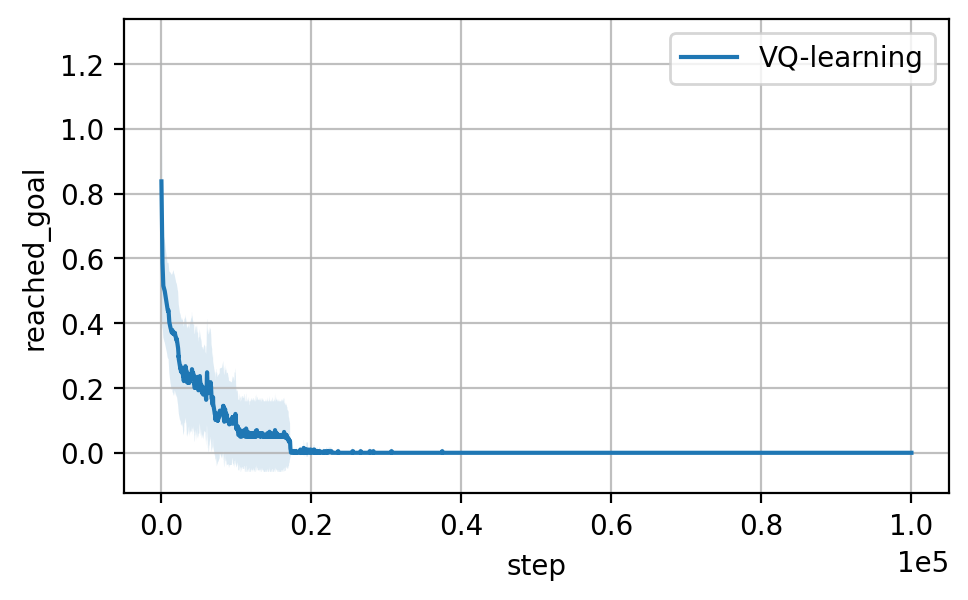

In [5]:
algo_name = "VQ-learning"
log_dir = log_dirs[algo_names.index(algo_name)]
key_name = "step"
# value_name = "reward"
# value_name = "maxQ"
value_name = "reached_goal"
# value_name = "len_episode"
x_label = key_name
y_label = value_name
label_name = algo_name
log_path = os.path.join(log_dir, "episodic.log")
save_path = os.path.join(log_dir, f"step-{value_name}")
# log_path = os.path.join('results/2rooms_steps30000_alphaQ0.1', "episodic.log")
plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=label_name, interpolate=True, smooth=10, max_key=True, save_path=save_path)

# key_name = "step"
# # value_name = "maxQ"
# value_name = "reward"
# label_name = "VQ-learning1.0"
# log_path = os.path.join('results/2rooms_steps100000_raninit1_alphaV0.1_alphaQ1.0_eps0.3to0.00_decay0.9998_repeat10', "episodic.log")
# plot_metric(log_path, key_name, value_name, label_name=label_name, interpolate=True, smooth=10, max_key=True)

### Plot one metric for one method specified by log_dir

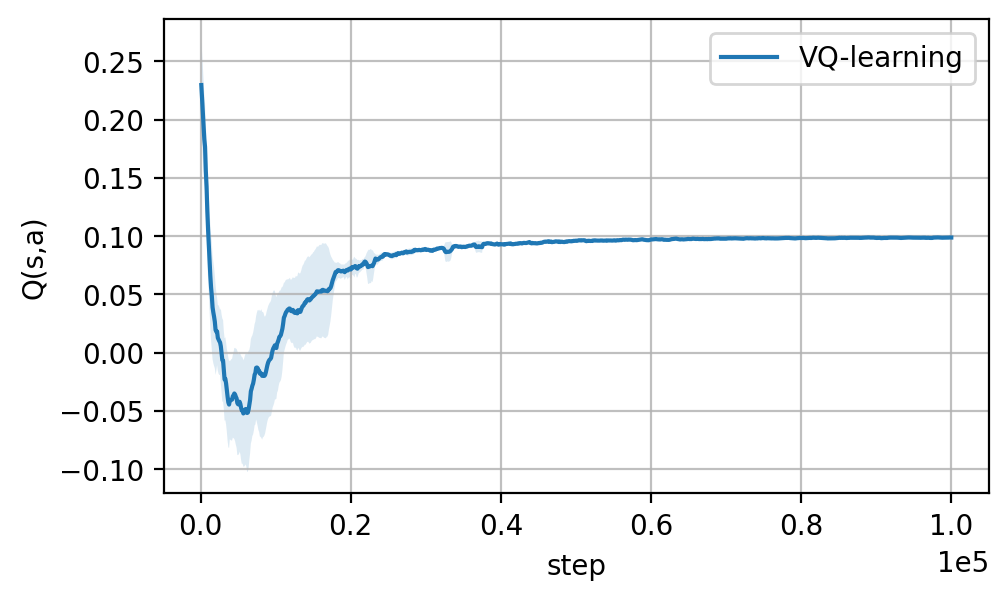

In [6]:
algo_name = "VQ-learning"
log_dir = log_dirs[algo_names.index(algo_name)]
key_name = "step"
value_name = "Q(s,a)"
# value_name = "maxQ"
# value_name = "eps"
# value_name = "temperature"
x_label = key_name
y_label = value_name
label_name = algo_name
# log_path = os.path.join(log_dir, "episodic.log")
log_path = os.path.join(log_dir, "avg_meter.log")
save_path = os.path.join(log_dir, f"step-{value_name}.png")

plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=label_name, interpolate=True, smooth=10, max_key=True, save_path=save_path)

### Plot estimated Q and the actual True Return of the method

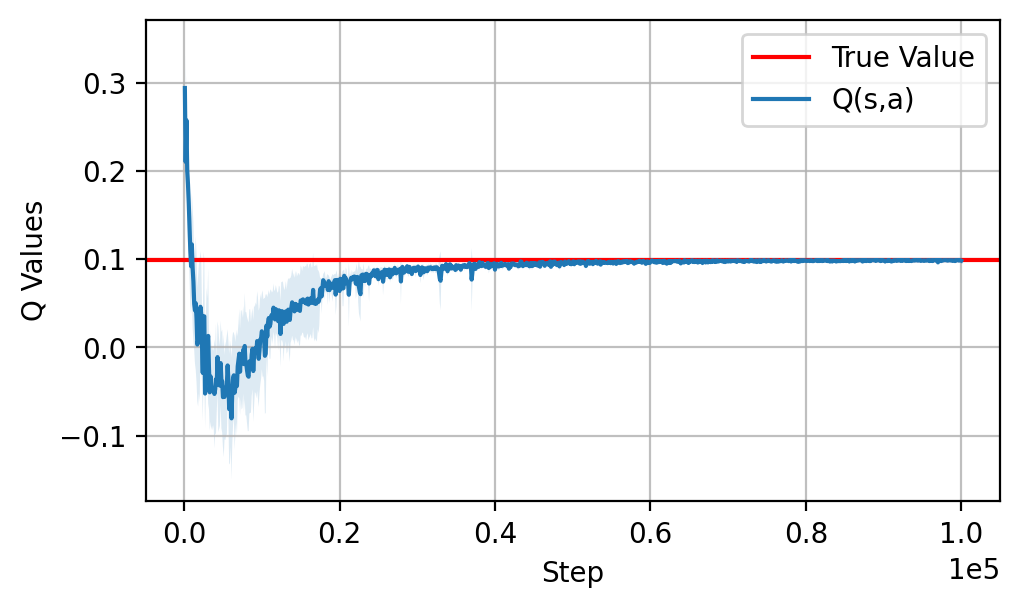

In [13]:
algo_name = "VQ-learning"
log_dir = log_dirs[algo_names.index(algo_name)]
x_label = "Step"
y_label = 'Q Values'

key_name = "step"
value_name = "Q(s,a)"
# value_name = "maxQ"
# value_name = "avg_max_Q"
curve_name = value_name

log_path_true_return = os.path.join(log_dir, "true_return.log")
plot_avg_true_Q(log_path_true_return)

log_path = os.path.join(log_dir, "avg_meter.log")
save_path = os.path.join(log_dir, "step-Q-TrueQ")

plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=False, smooth=1, max_key=True, save_path=False)



### Plot V and Q for VQ-learning

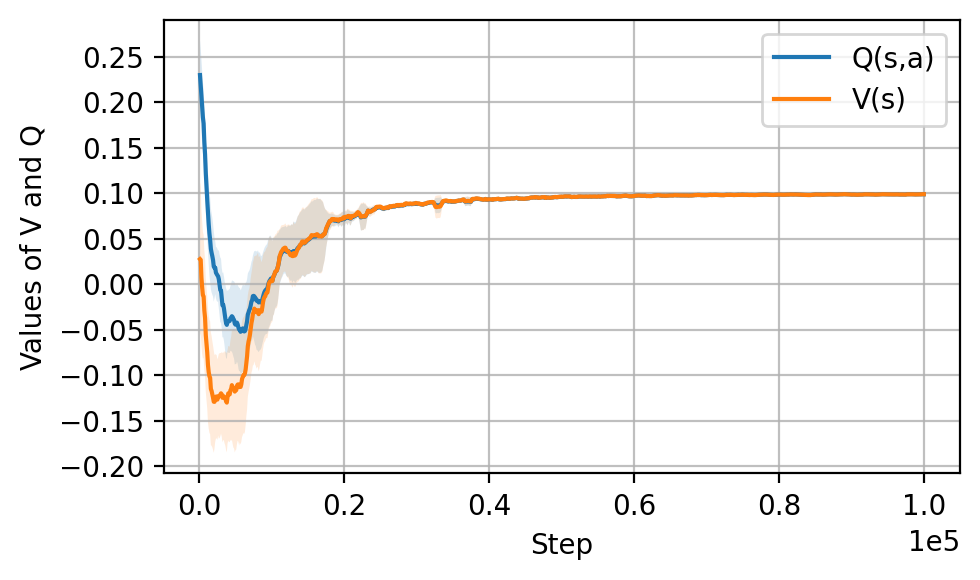

In [15]:
algo_name = "VQ-learning"
log_dir = log_dirs[algo_names.index(algo_name)]
x_label = "Step"
y_label = 'Values of V and Q'

key_name = "step"
value_name = "Q(s,a)"
# value_name = "maxQ"
curve_name = value_name

log_path = os.path.join(log_dir, "avg_meter.log")
save_path = os.path.join(log_dir, "step-V-Q")

plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=False, smooth=10, max_key=True, save_path=False)
value_name = "V(s)"
curve_name = value_name
plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=True, smooth=10, max_key=True, save_path=save_path)

# log_path_true_return = os.path.join(log_dir, "true_return.log")
# plot_avg_true_Q(log_path_true_return)



# log_path = os.path.join(log_dir, "avg_meter.log")
# x_label = "step"
# y_label = "Q(s,a)"
# plot_metric(log_path, x_label, y_label, label_name="Q(s,a)", interpolate=False)
# x_label = "step"
# y_label = "V(s)"
# plot_metric(log_path, x_label, y_label, label_name="V(s)", interpolate=False)

### Plot all runs

28936 99999
28604 99998
28801 99997
26223 99999
28722 99999
27724 99999
28641 99997
28840 99997
28637 99998
28761 99999
28618 99999
28479 99998
28253 99998
28932 99997
28738 99999
28661 99997
28136 99994
28642 99999
28557 99998
28955 99997


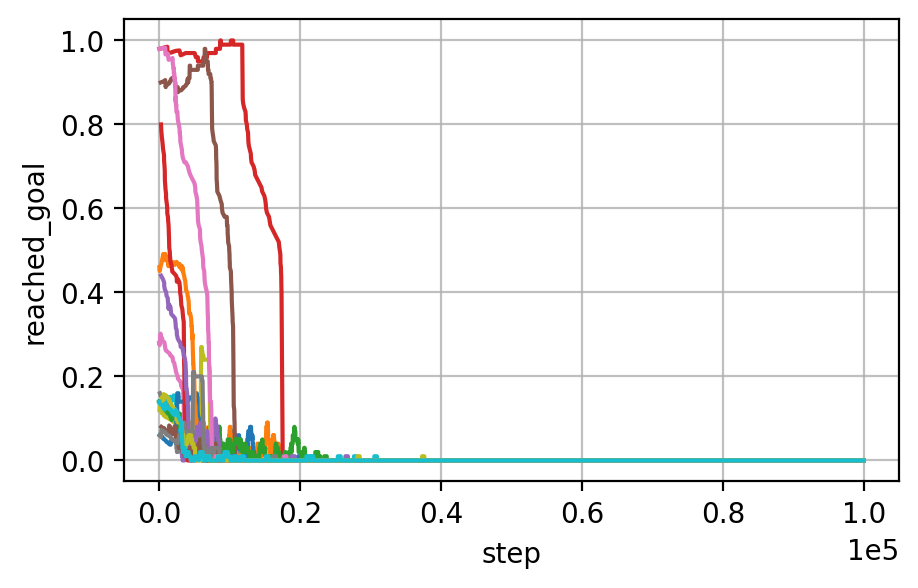

In [16]:
# log_dir = "results/2rooms_steps100000_raninit1_alphaV0.1_alphaQ1.0_eps0.3to0.00_decay0.9998_repeat10"
# log_dir = "results/2rooms_rwd0.1/VQ-learning/randinit1_eps0.5to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat20_steps200000"
# log_path = os.path.join(log_dir, "avg_meter.log")
algo_name = "VQ-learning"
log_dir = log_dirs[algo_names.index(algo_name)]
log_path = os.path.join(log_dir, "episodic.log")
x_label = "step"
# y_label = "reward"
# y_label = "maxQ"
y_label = "reached_goal" 
# y_label = "len_episode"


save_path = os.path.join(log_dir, f"step-{y_label}-allruns")

smooth=100

last_idice = []
with open(log_path, "r") as f:
    last_repeat_idx = 0
    for line_idx, line in enumerate(f):
        data = json.loads(line)
        if data["repeat_idx"] != last_repeat_idx:
            last_idice.append(line_idx-1)
            last_repeat_idx = data["repeat_idx"]

if line_idx != last_idice[-1]:
    last_idice.append(line_idx)
last_idice = np.array(last_idice)
# for i in range(n_repeat):
#     # count number of lines for repeat i
#     n_lines = 0
#     with open(log_path, "r") as f:
#         for line in f:
#             data = json.loads(line)
#             if data["repeat_idx"] == i:
#                 n_lines += 1
#     last_idice.append(n_lines)
# last_idice = np.array(last_idice)
# # each element is the sum of the previous elements
# last_idice = np.cumsum(last_idice)
# last_idice = last_idice - 1

keys = []
values = []

with open(log_path, "r") as f:
    for i, line in enumerate(f):
        data = json.loads(line)
        if x_label in data and y_label in data:
            keys.append(data[x_label])
            values.append(data[y_label])        
        if i in last_idice:
            keys, values = np.array(keys), np.array(values)
            print(len(keys), keys[-1])
            if smooth > 1 and values.shape[0] > 0:
                K = np.ones(smooth)
                ones = np.ones(values.shape[0])
                values = np.convolve(values, K, "same") / np.convolve(ones, K, "same")
            # plot data
            plt.plot(keys, values, label=f"rep_idx: {np.where(last_idice==i)[0][0]}")

            keys = []
            values = []


            
plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["figure.dpi"] = 200
plt.rcParams["font.size"] = 10
plt.grid(alpha=0.8)
# plt.ylim(top=2.0)
# plt.legend(ncol=1)
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
# save the plot to save_path
plt.savefig(f"{save_path}.png")
# plt.close()

### Compare algos, estimated Q values

In [32]:
log_dirs = [
    'results/2rooms_rwd0.1(-0.1,1)/Q-learning/randinit1_explore[0.5,0.0,0.9999]_buffer1_1_is0.0_noisyV0.0_repeat10_steps30000--TrueQ',
    'results/2rooms_rwd0.1(-0.1,1)/VQ-learning/randinit1_explore[0.5,0.0,0.9999]_buffer1_1_is0.0_noisyV0.0_repeat10_steps30000--TrueQ',
    'results/2rooms_rwd0.1(-0.1,1)/DoubleQ-learning/randinit1_explore[0.5,0.0,0.9999]_buffer1_1_is0.0_noisyV0.0_repeat10_steps30000--TrueQ',
    'results/2rooms_rwd0.1(-0.1,1)/SARSA/randinit1_explore[0.5,0.0,0.9999]_buffer1_1_is0.0_noisyV0.0_repeat10_steps30000--TrueQ',
    'results/2rooms_rwd0.1(-0.1,1)/ExpectedSARSA/randinit1_explore[0.5,0.0,0.9999]_buffer1_1_is0.0_noisyV0.0_repeat10_steps30000--TrueQ'
    ]

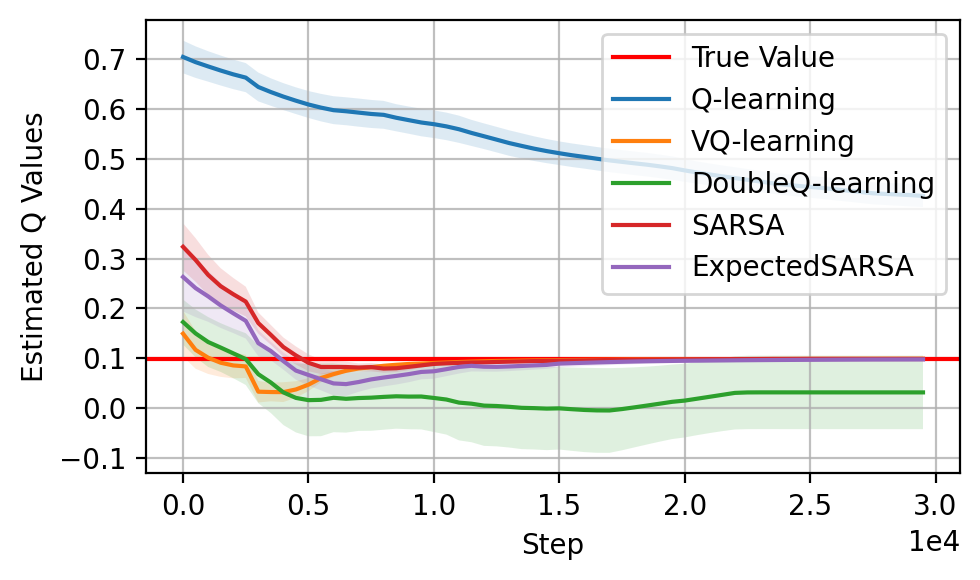

In [33]:
# mode = "episodic" 
# mode = "avg_meter"
# [version 1]:
# log_dir1 = "results/2rooms_randinit0_eps0.3to0.0_decay0.9998_buffer1_1_is0.0_syncVQ0_repeat5_steps30000"
# log_dir2 = "results/2rooms_randinit0_eps0.3to0.0_decay0.9998_buffer1_1_is0.0_syncVQ0_repeat5_steps30000_QLearning"
# log_dir3 = "results/2rooms_randinit0_eps0.3to0.0_decay0.9998_buffer1_1_is0.0_syncVQ0_repeat5_steps30000_DoubleQLearning"

# if mode == "episodic":
#     log_path1 = os.path.join(log_dir1, "episodic.log")
#     log_path2 = os.path.join(log_dir2, "episodic.log")
# else:
#     log_path1 = os.path.join(log_dir1, "avg_meter.log")
#     log_path2 = os.path.join(log_dir2, "avg_meter.log")
# save_path1 = os.path.join(log_dir1, "step-reward-compare-algos.png")
# save_path2 = os.path.join(log_dir2, "step-reward-compare-algos.png")
# print(log_path1)
# curve_name1 = "VQ-learning"
# curve_name2 = "Q-learning"
# key_name = x_label = "step"
# value_name = y_label = "reward"
# smooth=10


# plot_metric(log_path1, key_name, value_name, x_label, y_label, label_name=curve_name1, interpolate=True, smooth=10, max_key=True, save_path=False)
# plot_metric(log_path2, key_name, value_name, x_label, y_label, label_name=curve_name2, interpolate=True, smooth=10, max_key=True, save_path=save_path1)

# [version 2]:
# log_dirs = {
#     # "Q-learning" : "results/2rooms_randinit0_eps0.3to0.0_decay0.9998_buffer1_1_is0.0_syncVQ0_repeat5_steps30000_QLearning",
#     "Q-learning": "results/2rooms/Q-learning/randinit1_eps0.3to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat10_steps60000",
#     # "DoubleQ-learning" : 'results/2rooms/DoubleQ-learning/randinit1_eps0.3to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat10_steps30000',
#     "DoubleQ-learning": "results/2rooms/DoubleQ-learning/randinit1_eps0.3to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat10_steps60000",
#     # "VQ-learning" : "results/2rooms_randinit0_eps0.3to0.0_decay0.9998_buffer1_1_is0.0_syncVQ0_repeat5_steps30000",
#     "VQ-learning": 'results/2rooms/VQ-learning/randinit1_eps0.3to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat10_steps60000'
# }
# log_dirs = {
#     "Q-learning": 'results/2rooms/Q-learning/randinit1_eps0.3to0.0_decay0.9999_buffer1_1_is0.0_syncVQ0_repeat20_steps60000',
#     "DoubleQ-learning": 'results/2rooms/DoubleQ-learning/randinit1_eps0.3to0.0_decay0.9999_buffer1_1_is0.0_syncVQ0_repeat20_steps60000',
#     "VQ-learning": 'results/2rooms/VQ-learning/randinit1_eps0.3to0.0_decay0.9999_buffer1_1_is0.0_syncVQ0_repeat20_steps60000'
# }

# algos = [
#     "Q-learning", 
#     "DoubleQ-learning", 
#     "VQ-learning", 
#     "SARSA", 
#     "ExpectedSARSA"
# ]
# dirs = [
#     'randinit1_eps0.5to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat20_steps200000',
#     'randinit1_eps0.5to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat20_steps200000',  
#     'randinit1_eps0.5to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat20_steps200000',    
# ]
# dirs = [
#     'randinit1_eps0.5to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat15_steps100000--TrueQ',
#     'randinit1_eps0.5to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat15_steps100000--TrueQ',  
#     'randinit1_eps0.5to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat15_steps100000--TrueQ',    
#     'randinit1_eps0.5to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat15_steps100000--TrueQ',
#     'randinit1_eps0.5to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat15_steps100000--TrueQ',
# ]

# log_dirs = {}

# file_name = "episodic.log"
# file_name = "avg_meter.log"
file_name = "eval.log"
# file_name = "true_return.log"

key_name = "step"
x_label = "Step"

# value_name = y_label = "reward"
# value_name = "reached_goal"
value_name = "avg_max_Q"

# y_label = "Prob reaching Goal#1"
y_label = "Estimated Q Values"

if y_label == "Estimated Q Values":
    for log_dir in log_dirs:
        if log_dir.split('/')[2] == "VQ-learning":
            log_path_true_return = os.path.join(log_dir, "true_return.log") # better make sure the first algo is the one with true return
            plot_avg_true_Q(log_path_true_return)

# log_dirs = {}
# for algo, dir in zip(algos, dirs):
#     log_dirs[algo] = f"results/2rooms_rwd0.1(-0.1,1)/{algo}/{dir}"
for log_dir in log_dirs:
    log_path = os.path.join(log_dir, file_name)
    curve_name = log_dir.split('/')[2]

    plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=True, smooth=10, max_key=True, save_path=False)

if value_name == "reached_goal":
    plt.ylim(-0.1, 1.1)
plt.legend(loc="upper right", ncol=1)

save_dir = os.path.join(log_dirs[0])
save_path = os.path.join(save_dir, f"step-{value_name}-acrossAlgos")
# create save_dir if not exists 
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
if save_path:
    plt.savefig(f"{save_path}")


# log_dir = "results/2rooms_randinit0_eps0.3to0.0_decay0.9998_buffer1_1_is0.0_syncVQ0_repeat5_steps30000"
# key_name = "step"
# value_name = "reward"
# # value_name = "maxQ"
# x_label = key_name
# y_label = value_name
# label_name = algo_name
# log_path = os.path.join(log_dir, "episodic.log")
# print(log_path)
# save_path = os.path.join(log_dir, "step-reward.png")
# # log_path = os.path.join('results/2rooms_steps30000_alphaQ0.1', "episodic.log")
# plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=label_name, interpolate=True, smooth=10, max_key=True, save_path=False)


## Compare algos, reached_goal

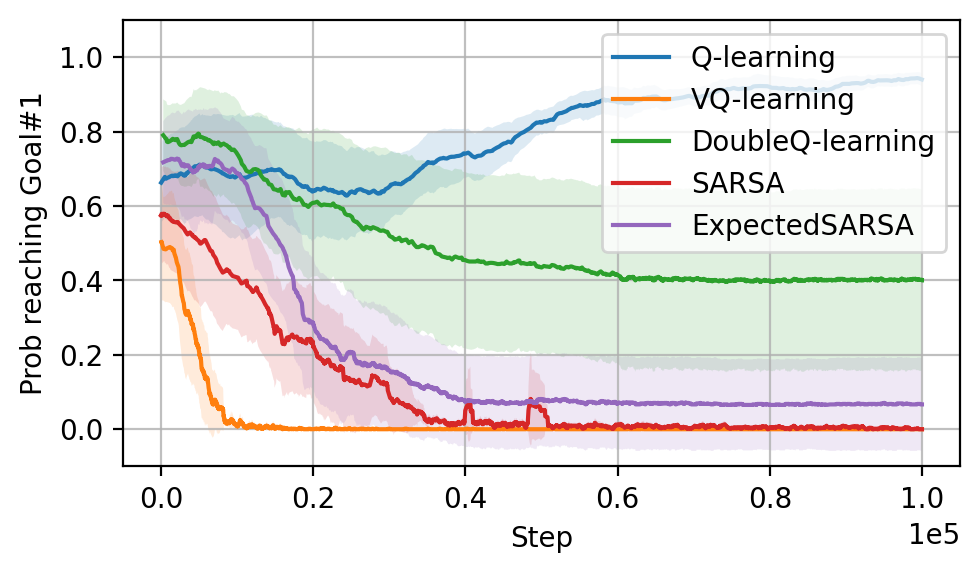

In [30]:
file_name = "episodic.log"

key_name = "step"
x_label = "Step"

# value_name = y_label = "reward"
value_name = "reached_goal"
# value_name = "avg_max_Q"

y_label = "Prob reaching Goal#1"
# y_label = "Estimated Q Values"

for log_dir in log_dirs:
    log_path = os.path.join(log_dir, file_name)
    curve_name = log_dir.split('/')[2]
    plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=True, smooth=50, max_key=True, save_path=False)

if value_name == "reached_goal":
    plt.ylim(-0.1, 1.1)
plt.legend(loc="upper right", ncol=1)

save_dir = os.path.join(log_dirs[0])
save_path = os.path.join(save_dir, f"step-{value_name}-acrossAlgos")
# create save_dir if not exists 
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
if save_path:
    plt.savefig(f"{save_path}")